In [8]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load network (update path)
nodes20 = "pypsa-eur/resources/germany-test/networks/base_s_20_elec_.nc"
nodes_adm = "pypsa-eur/resources/germany-adm/networks/base_s_adm_elec_.nc"

NETWORK_PATH = nodes_adm
n = pypsa.Network(NETWORK_PATH)

print(f"Network loaded: {len(n.buses)} buses, {len(n.lines)} lines")

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


Network loaded: 114 buses, 80 lines


Buses: 114
Lines: 80
Generators: 354
Snapshots: 7
Countries: ['DE']


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x7424ed8ed950>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x7424ed8eda90>,
  'Line': <matplotlib.collections.LineCollection at 0x7424ed8edbd0>},
 'flows': {}}

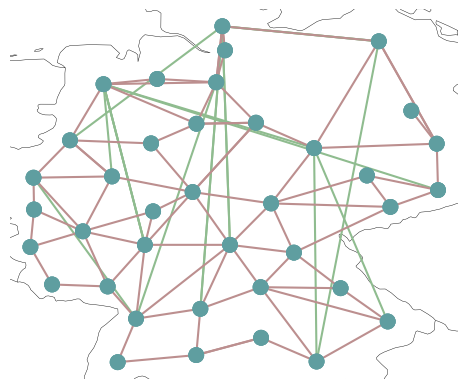

In [ ]:
print("Buses:", len(n.buses))
print("Lines:", len(n.lines))
print("Generators:", len(n.generators))
print("Snapshots:", len(n.snapshot_weightings))
print("Countries:", n.buses.country.unique())

# Plot
n.plot()

                   sum  count
carrier                      
CCGT           30783.0     38
OCGT            6113.0     38
biomass         8020.0     38
coal           20352.0     20
geothermal        27.0      2
lignite        19457.0     14
offwind-ac     11164.0      7
offwind-dc         0.0      3
offwind-float      0.0      7
oil             5684.0     38
onwind         73332.0     38
solar          48771.0     38
solar-hsat         0.0     38
waste           3128.0     35

Total inertia capacity: 57,248 MW


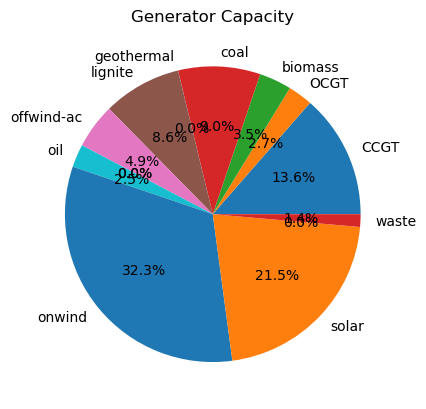

In [10]:
gen_summary = n.generators.groupby('carrier')['p_nom'].agg(['sum', 'count']).round(0)
print(gen_summary)

# Inertia carriers
inertia_carriers = ['CCGT', 'OCGT', 'coal']
inertia_cap = gen_summary.loc[inertia_carriers, 'sum'].sum()
print(f"\nTotal inertia capacity: {inertia_cap:,.0f} MW")

gen_summary['sum'].plot(kind='pie', autopct='%1.1f%%')
plt.title("Generator Capacity")
plt.ylabel('')
plt.savefig("generators_pie.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
loads = n.loads_t.p_set.sum()
print(loads)

name
DE11    25771.533121
DE12    14766.368515
DE13    11262.291810
DE14    11381.637375
DE21    28401.409043
DE22     6551.488098
DE23     6122.866849
DE24     5245.313405
DE25     9051.813942
DE26     6992.100310
DE27     9924.800974
DE30    12282.326742
DE40     8937.222101
DE50     3606.528515
DE60     9568.491350
DE71    19744.281848
DE72     4457.331997
DE73     6040.045313
DE80     4834.482667
DE91    12679.882097
DE92     9711.690362
DE93     6389.499190
DE94    11236.023145
DEA1    24509.785007
DEA2    19704.807625
DEA3    10585.880157
DEA4    10027.832138
DEA5    16554.193310
DEB1     6423.588183
DEB2     2040.224478
DEB3    10958.282584
DEC0     4474.887585
DED2     6277.521841
DED4     5606.388388
DED5     3711.665679
DEE0     9236.638172
DEF0    10529.106123
DEG0     8269.702311
dtype: float64


In [12]:
# --- Network object overview ---
print(f"Network name: {getattr(n, 'name', 'N/A')}")
print(f"Snapshots: {len(n.snapshots)} | Investment periods: {getattr(n, 'investment_periods', [])}")
print(f"Objective available: {'objective' in dir(n)}")

component_counts = pd.Series({
    "buses": len(n.buses),
    "lines": len(n.lines),
    "links": len(n.links),
    "generators": len(n.generators),
    "loads": len(n.loads),
    "storage_units": len(n.storage_units),
    "stores": len(n.stores),
    "transformers": len(n.transformers),
})

print("\nComponent counts:")
display(component_counts.to_frame("count"))

print("\nCarriers per major component:")
for comp_name, comp_df in {
    "generators": n.generators,
    "loads": n.loads,
    "lines": n.lines,
    "links": n.links,
    "storage_units": n.storage_units,
}.items():
    if not comp_df.empty and "carrier" in comp_df.columns:
        print(f"- {comp_name}: {comp_df['carrier'].nunique()} carriers")
    else:
        print(f"- {comp_name}: no carrier column or empty")

Network name: Unnamed Network
Snapshots: 7 | Investment periods: Index([], dtype='object', name='period')
Objective available: True

Component counts:


,count
buses,114
lines,80
links,170
generators,354
loads,38
storage_units,0
stores,76
transformers,0



Carriers per major component:
- generators: 14 carriers
- loads: 1 carriers
- lines: 1 carriers
- links: 5 carriers
- storage_units: no carrier column or empty


In [13]:
# --- Capacity and topology diagnostics ---
if not n.generators.empty:
    cap_by_carrier = n.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=False)
    print("Installed generator capacity by carrier [MW]:")
    display(cap_by_carrier.head(20).to_frame("p_nom_MW"))

    cap_by_bus = n.generators.groupby("bus")["p_nom"].sum().sort_values(ascending=False)
    print("\nTop buses by installed generation capacity [MW]:")
    display(cap_by_bus.head(15).to_frame("p_nom_MW"))

if not n.loads.empty and hasattr(n.loads_t, "p_set") and not n.loads_t.p_set.empty:
    annual_load_by_bus = n.loads_t.p_set.sum().sort_values(ascending=False)
    print("\nTop buses by annual load [MWh over snapshots]:")
    display(annual_load_by_bus.head(15).to_frame("load_MWh"))

if not n.lines.empty:
    print("\nLine length statistics [km]:")
    if "length" in n.lines.columns:
        display(n.lines["length"].describe().to_frame("value"))
    else:
        print("No 'length' column in n.lines")

Installed generator capacity by carrier [MW]:


,p_nom_MW
carrier,
onwind,73332.065900
solar,48771.254020
CCGT,30783.128330
coal,20351.945000
lignite,19457.035000
offwind-ac,11163.743000
biomass,8020.001833
OCGT,6112.743723
oil,5684.345986



Top buses by installed generation capacity [MW]:


,p_nom_MW
bus,
DE40,23511.917294
DE94,20368.556258
DEF0,15060.494546
DEE0,13177.477269
DEA2,12117.648125
DEA1,12038.251798
DE80,11469.032026
DEA3,8994.532630
DE12,8376.286577



Top buses by annual load [MWh over snapshots]:


,load_MWh
name,
DE21,28401.409043
DE11,25771.533121
DEA1,24509.785007
DE71,19744.281848
DEA2,19704.807625
DEA5,16554.193310
DE12,14766.368515
DE91,12679.882097
DE30,12282.326742



Line length statistics [km]:


,value
count,80.000000
mean,105.711809
std,38.215307
min,48.047539
25%,80.554636
50%,93.317161
75%,121.309970
max,226.111347
